# Predicting TP53 Mutation Status from Gene Expression

**Course project — Machine Learning Lab (Prof. Francesca M. Buffa)**

**Authors:** Tommaso Errico, Edoardo Paccagnella, Federico Ferrari, Rebecca Rinero

**Academic year:** 2025–2026


## Abstract

In this project, we use gene expression profiles from the **CCLE / DepMap Public 26Q1** release to predict TP53 mutation status. We consider two tasks:

- **Task 1 — binary classification:** mutated cells vs wild-type cells (WT)
- **Task 2 — multi-class classification:** type of mutation using two alternative label definitions: coding consequence vs DNA-level mutation type

For Task 1, we compare standard ML models on gene expression features and evaluate both a simple train/test split and cross-validation strategies that account for tissue effects. For Task 2, we compare the same modelling pipeline across the two mutation taxonomies to understand which label definition is more consistent with transcriptomic data.

Overall, the results suggest that TP53 mutation status can be predicted from gene expression with good performance, and that coding-consequence labels are more informative than DNA-level labels for the multi-class setting.

## 0. Setup

This notebook loads pre-computed results from `output_tp53/` by default. 
Setting `RUN_HEAVY = True` re-runs all training pipelines from scratch.


In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

DATA_DIR = Path('data')             # Cartella dati grezzi/intermedi
OUTPUT_DIR = Path('output_tp53')    # Cartella per i risultati salvati
RANDOM_STATE = 42                   # Seed fisso per ottenre risultati riproducibili
RUN_HEAVY = False                   # Se True riesegue training e pipeline più lunghe

## 1. Biological background

### Why TP53?

TP53 is the gene that encodes the p53 protein, a key regulator of cell-cycle control, DNA repair, and apoptosis.  
When TP53 is altered, these processes may be disrupted, and this can affect the expression of downstream genes.

For this reason, we expect TP53 mutation status to leave a signal in gene expression data.  
The goal of this project is to test whether machine learning models can detect that signal.

We consider two tasks:

| Task | Type | Classes |
|---|---|---|
| 1 | Binary | `WT` vs `Mutated` |
| 2 | Multi-class | type of mutation — **two competing taxonomies** (see §4) |

### Working hypothesis

If TP53 is mutated, the expression profile of the sample may reflect changes in genes regulated by the p53 pathway.  
We test if expression data contain enough information to predict TP53 status.

## 2. Data sources

We use the **DepMap Public 26Q1** release of the Cancer Cell Line Encyclopedia (CCLE, released 2026-04-01).

| File | Content | Main use |
|---|---|---|
| `OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv` | Log-transformed TPM expression values for protein-coding genes across CCLE cell lines | Input features for all models |
| `OmicsSomaticMutationsMatrixDamaging.csv` | Gene-by-sample matrix summarizing damaging somatic mutations | Definition of the binary TP53 label for Task 1 |
| `OmicsSomaticMutations.csv` | Variant-level somatic mutation annotations | Definition of mutation-type labels for Task 2 |
| `Model.csv` | Metadata for CCLE cell lines, including lineage and disease annotation | Sample annotation and tissue-aware evaluation |
| `OmicsProfiles.csv` | Metadata on sequencing / omics profiles linked to samples | Consistency checks and dataset integration |

The raw files are not included in the repository because of their size.  
The notebook loads precomputed outputs, while the full preprocessing and training steps are available in the `scripts/` folder.

## 3. Master dataset

We merge gene expression data, TP53 mutation information, and cell-line metadata into a single dataset at the **cell-line level**.

This step is used to build one consistent table for downstream machine learning, with:
- **features** = gene expression values
- **label** = TP53 mutation status
- **metadata** = cell line annotation such as lineage

Main steps:
1. Load expression, mutation, and metadata tables
2. Keep one default profile for each model
3. Merge the tables using `ModelID`
4. Define the binary label for Task 1 from TP53 damaging mutation information
5. Remove variables that would cause leakage, such as direct TP53 mutation or TP53 expression column


Final shape: **1,643 cell lines × 19,214 expression features**.

In [ ]:
# Carichiamo il dataset finale già processato
master = pd.read_csv(OUTPUT_DIR / 'datasets/master.csv')
print(f'Master dataset shape: {master.shape}')

preview_cols = ['ModelID', 'CellLineName', 'OncotreeLineage', 'TP53_expression', 'TP53_damaging_score', 'task1_tp53_mutated']
display(master[preview_cols].head(5))

Master dataset shape: (1643, 19232)


,ModelID,CellLineName,OncotreeLineage,TP53_expression,TP53_damaging_score,task1_tp53_mutated
0,ACH-001113,LC-1/sq-SF,Lung,4.876900,2.0,1
1,ACH-001289,COG-AR-359,CNS/Brain,5.045710,0.0,0
2,ACH-001339,Colo 794,Skin,5.928031,2.0,1
3,ACH-001979,NZM11,Skin,5.190481,0.0,0
4,ACH-002438,CCLF_PEDS_0026_T,Kidney,5.537262,0.0,0


## 4. Task 1 — Binary classification (mutated vs WT)

### 4.1 Label

For Task 1, we define a binary label based on the DepMap TP53 damaging-mutation matrix:
`task1_tp53_mutated = (TP53_damaging_score > 0)`

This gives a simple sample-level target:
- `0` = WT
- `1` = Mutated

We use this label for the binary classification task, while gene expression values are used as input features.

,n,pct
task1_tp53_mutated,,
WT,670,40.8
Mutated,973,59.2


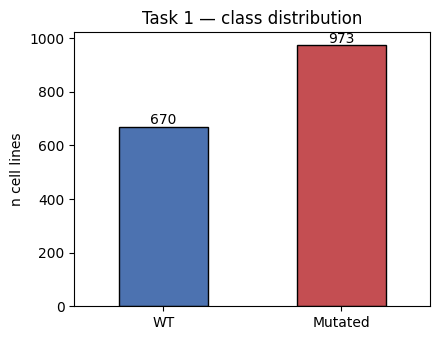

In [ ]:
# Controlliamo la distribuzione delle classi
label_counts = (master['task1_tp53_mutated'].value_counts().sort_index() .rename(index={0: 'WT', 1: 'Mutated'}) .to_frame('n'))
# Aggiungiamo la percentuale per leggere meglio la distribuzione
label_counts['pct'] = (label_counts['n'] / label_counts['n'].sum() * 100).round(1)
display(label_counts)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
label_counts['n'].plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='black')

ax.set_title('Task 1 — class distribution')
ax.set_ylabel('n cell lines')
ax.set_xlabel('')

for i, v in enumerate(label_counts['n']):
    ax.text(i, v + 8, str(v), ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Baseline — single 80/20 split

As a first test, we train 3 standard ML models using an 80/20 train/test split on the full set of 19,214 expression features.

The models are:
- **Logistic Regression**
- **Random Forest**
- **XGBoost**

We use stratification to preserve the WT / Mutated class proportions in both splits.  
Class weighting is set to `balanced` for consistency across experiments.

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.8815,0.8679,0.9436,0.9042,0.9276
1,Logistic Regression,0.8693,0.8958,0.8821,0.8889,0.9208
2,Random Forest,0.8328,0.8017,0.9538,0.8712,0.8982


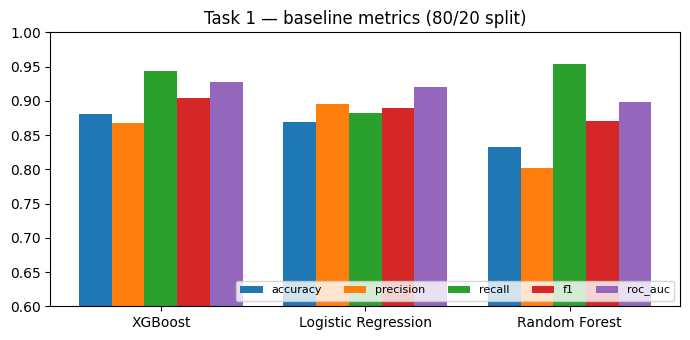

In [ ]:
# Carichiamo le metriche dei modelli sullo split 80/20
task1_baseline = pd.read_csv(OUTPUT_DIR / 'task1/model_comparison.csv')
display(task1_baseline.round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(task1_baseline))
width = 0.16
for i, m in enumerate(metrics):
    ax.bar(x + i*width, task1_baseline[m], width, label=m)

# Confrontiamo le metriche dei tre modelli
ax.set_xticks(x + 2*width)
ax.set_xticklabels(task1_baseline['model'], rotation=0)
ax.set_ylim(0.6, 1.0)
ax.set_title('Task 1 — baseline metrics (80/20 split)')
ax.legend(loc='lower right', fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

**Hyperparameter search.** We also ran a small 5-fold `GridSearchCV` on XGBoost as a control experiment, using the top 2,000 genes by variance. The best ROC-AUC (**0.9097**) was very similar to the baseline configuration, so we kept the default setting for the rest of the analysis. The full tuning results are available in `output_tp53/task1_tuning_results.csv`.

### 4.3 Cross-validation with tissue control

To make the evaluation more robust, we repeated Task 1 under three validation settings (`train_task1_cv.py`):

| Scenario | Setup | Purpose |
|---|---|---|
| **A** | StratifiedKFold (5-fold) | Standard in-distribution evaluation |
| **B** | GroupKFold by tissue | Test generalization to unseen tissues |
| **C** | Tissue-only baseline | Measure how much prediction comes from tissue identity alone |

This comparison helps us separate a true TP53-related expression signal from tissue-specific effects.

,scenario,mean_auc,std_auc
0,A) Standard 5-fold CV,0.8981,0.0168
1,B) GroupKFold per tessuto,0.8489,0.0557
2,C) Tissue-only baseline,0.7533,0.0276


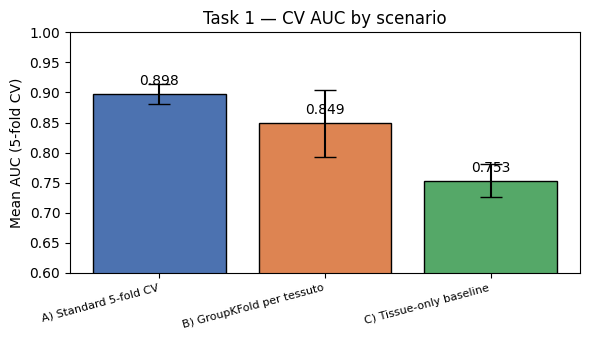

In [ ]:
# Risultati della cross-validation nei tre scenari
task1_cv = pd.read_csv(OUTPUT_DIR / 'task1/cv_comparison.csv')
display(task1_cv.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))

ax.bar(task1_cv['scenario'], task1_cv['mean_auc'], yerr=task1_cv['std_auc'], capsize=8, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Mean AUC (5-fold CV)')
ax.set_title('Task 1 — CV AUC by scenario')
ax.tick_params(axis='x', labelsize=8)

# Aggiungo il valore medio sopra ogni barra
for i, v in enumerate(task1_cv['mean_auc']):
    ax.text(i, v + 0.015, f'{v:.3f}', ha='center')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

The three scenarios give a more complete view of model performance:

- **Scenario A** shows that the model performs well under standard cross-validation.
- **Scenario B** shows a moderate drop when tissues in the test set are not seen during training.
- **Scenario C** shows that tissue identity alone already carries some predictive signal.

Overall, these results suggest that part of the performance is related to tissue context, but gene expression still provides additional information beyond tissue alone.

### 4.4 Per-tissue breakdown

Using `LeaveOneGroupOut`, we evaluate the model with a leave-one-tissue-out strategy.  
Only tissues with at least 15 samples and both classes represented are included.

,tissue,n,n_mut,mut_rate_%,auc
0,Eye,23,1,4.3,1.000
1,Bladder/Urinary Tract,37,29,78.4,0.987
2,Uterus,43,29,67.4,0.953
3,Skin,119,38,31.9,0.951
4,Pleura,22,4,18.2,0.931
5,Thyroid,22,16,72.7,0.917
6,Ovary/Fallopian Tube,66,49,74.2,0.916
7,Bowel,84,64,76.2,0.890
8,CNS/Brain,96,60,62.5,0.885
9,Soft Tissue,77,29,37.7,0.846


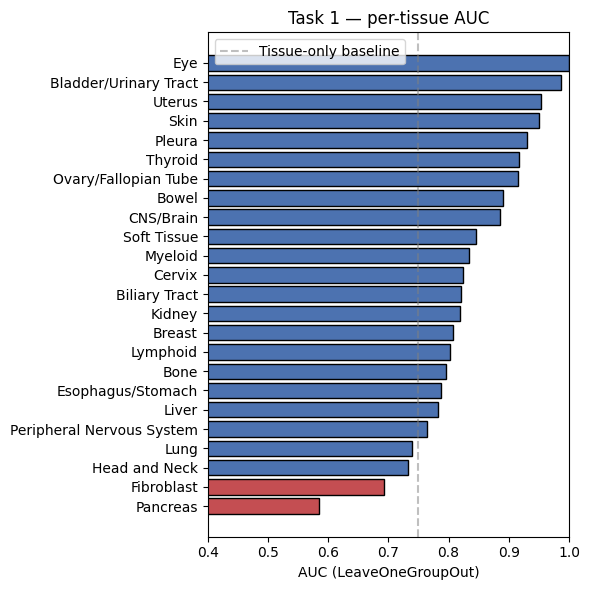

In [ ]:
# Carico l'AUC ottenuta lasciando fuori un tessuto alla volta
task1_tissue = pd.read_csv(OUTPUT_DIR / 'task1/per_tissue_auc.csv')
display(task1_tissue.sort_values('auc', ascending=False).round(3))

fig, ax = plt.subplots(figsize=(6, 6))
tissue_sorted = task1_tissue.sort_values('auc')
colors = ['#C44E52' if a < 0.7 else '#4C72B0' for a in tissue_sorted['auc']]

# Evidenzio in rosso i tessuti con performance piu basse
ax.barh(tissue_sorted['tissue'], tissue_sorted['auc'], color=colors, edgecolor='black')
ax.axvline(0.75, color='gray', linestyle='--', alpha=0.5, label='Tissue-only baseline')
ax.set_xlim(0.4, 1.0)
ax.set_xlabel('AUC (LeaveOneGroupOut)')
ax.set_title('Task 1 — per-tissue AUC')
ax.legend()
plt.tight_layout()
plt.show()

**Tissue outliers**

- **Pancreas** is the clearest low-performance case.
- **Lung** and **Head & Neck** are less stable because the WT class is relatively small.

These cases suggest that class imbalance and tissue-specific biology can affect generalization.

### 4.5 Feature importance

We inspect feature importance to check if the model is using biologically meaningful genes.

In particular, if the classifier is capturing a real TP53-related signal, we expect important features to include genes from the p53 pathway and its downstream transcriptional targets.

In [ ]:
rf_imp = pd.read_csv(OUTPUT_DIR / 'task1/rf_feature_importance.csv')
xgb_imp = pd.read_csv(OUTPUT_DIR / 'task1/xgb_feature_importance.csv')

# Lista di geni noti del pathway / regolazione p53 usata come controllo biologico
p53_canonical = {'MDM2', 'MDM4', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'DDB2', 'RRM2B', 'ZMAT3', 'SESN1', 'SESN2', 'GADD45A', 
                 'FDXR', 'PHLDA3', 'AEN', 'TNFRSF10B', 'RPS27L', 'SPATA18', 'BTG2', 'TP53I3', 'TP53AIP1', 'CCNG1', 'XPC', 
                 'PERP', 'FAS', 'EDA2R'}

rf_top20 = rf_imp.head(20).copy()
rf_top20['canonical_p53_target'] = rf_top20['feature'].isin(p53_canonical)

print('Random Forest — top 20 features:')
display(rf_top20)

rf_overlap = rf_top20['canonical_p53_target'].sum()
print(f'\nCanonical p53 targets in RF top-20: {rf_overlap}/20')

xgb_top20 = xgb_imp.head(20).copy()
xgb_top20['canonical_p53_target'] = xgb_top20['feature'].isin(p53_canonical)
print('\nXGBoost — top 20 features:')
display(xgb_top20)
xgb_overlap = xgb_top20['canonical_p53_target'].sum()
print(f'\nCanonical p53 targets in XGBoost top-20: {xgb_overlap}/20')

Random Forest — top 20 features:


,feature,importance,canonical_p53_target
0,MDM2,0.012198,True
1,EDA2R,0.006890,True
2,ZMAT3,0.006320,True
3,PTCHD4,0.006003,False
4,AEN,0.005579,True
5,CDKN1A,0.005475,True
6,FDXR,0.004746,True
7,SPATA18,0.004199,True
8,SESN1,0.004048,True
9,PHLDA3,0.003769,True



Canonical p53 targets in RF top-20: 15/20

XGBoost — top 20 features:


,feature,importance,canonical_p53_target
0,EDA2R,0.006871,True
1,OTX1,0.004690,False
2,HEATR4,0.004143,False
3,C4orf46,0.004079,False
4,CADM3,0.003752,False
5,CPSF4,0.002882,False
6,GNB2,0.002778,False
7,GRHL2,0.002708,False
8,GAB1,0.002672,False
9,CFAP299,0.002624,False



Canonical p53 targets in XGBoost top-20: 2/20


The feature-importance analysis is consistent with the biological role of TP53.

Several top-ranked genes are known p53-related targets, which suggests that the model is not relying only on arbitrary patterns in the data. At the same time, some model-specific differences remain, especially for XGBoost, which may also capture part of the tissue-related structure already discussed above.

### 4.6 Gene-level correlation with TP53 status

As an additional analysis, we compute the Pearson correlation between each gene and the binary TP53 label.
This is a simple model-free analysis that helps us verify if the same genes are associated with TP53 status.

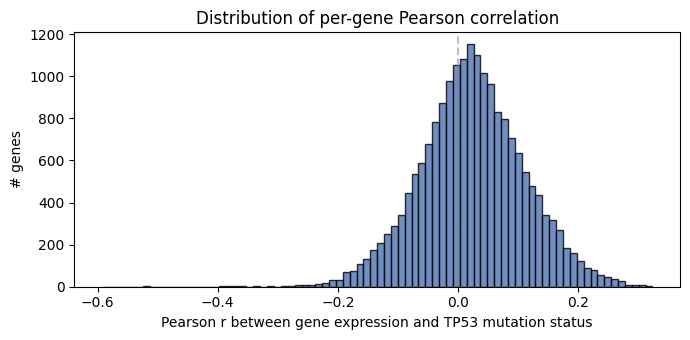

Top 15 genes negatively correlated with mutation status (lower expression in mutated cell lines):


,gene,pearson_r
0,EDA2R,-0.592911
1,RPS27L,-0.515019
2,MDM2,-0.513996
3,ZMAT3,-0.493723
4,CDKN1A,-0.486318
5,BAX,-0.397326
6,RRM2B,-0.396630
7,SESN1,-0.386422
8,SPATA18,-0.383861
9,PTCHD4,-0.381215


In [ ]:
# Selezioniamo solo le espression columns, escludendo label e metadata
expr_cols_corr = [c for c in master.columns if c not in {'Unnamed: 0', 'SequencingID', 'ModelConditionID', 'ModelID',
    'IsDefaultEntryForMC', 'IsDefaultEntryForModel', 'IsDefaultEntryForModel_bool', 'TP53_expression', 'TP53_damaging_score',
    'task1_tp53_mutated', 'task2_mutation_type', 'CellLineName', 'CCLEName', 'OncotreeLineage', 'OncotreePrimaryDisease',
    'OncotreeSubtype', 'Sex', 'AgeCategory', 'PrimaryOrMetastasis'}]

X_corr = master[expr_cols_corr].fillna(master[expr_cols_corr].median()).values
y_corr = master['task1_tp53_mutated'].values.astype(float)

# Correlazione di Pearson tra ogni gene e la label binaria
yc = y_corr - y_corr.mean()
Xc = X_corr - X_corr.mean(axis=0)
num = (Xc * yc[:, None]).sum(axis=0)
den = np.sqrt((Xc**2).sum(axis=0) * (yc**2).sum())
pearson_r = num / (den + 1e-12)

corr_df = pd.DataFrame({'gene': expr_cols_corr, 'pearson_r': pearson_r})
corr_df = corr_df.sort_values('pearson_r')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(corr_df['pearson_r'], bins=80, color='#4C72B0', edgecolor='black', alpha=0.8)
ax.axvline(0, c='gray', ls='--', alpha=0.5)
ax.set_xlabel('Pearson r between gene expression and TP53 mutation status')
ax.set_ylabel('# genes')
ax.set_title('Distribution of per-gene Pearson correlation')
plt.tight_layout(); plt.show()

print('Top 15 genes negatively correlated with mutation status (lower expression in mutated cell lines):')
display(corr_df.head(15).reset_index(drop=True))

The correlation analysis supports the same conclusion as the feature-importance results.

Genes with the strongest association to TP53 status include several known p53-related genes, giving an additional and model-independent confirmation that the signal captured by the classifiers is biologically meaningful.

### 4.7 MLP (PyTorch) — Task 1

We add a multi-layer perceptron to the model roster to test whether depth helps over the linear and tree-based classifiers. 
The goal is not to optimize a deep architecture, but to test whether a neural-network model can improve over the simpler baselines.

Main settings:
- two hidden layers
- batch normalization and dropout
- cross-entropy loss with class weights
- Adam optimizer
- 5-fold cross-validation

,task,n_samples,accuracy,macro_f1,weighted_f1
0,task1,1643,0.8247,0.8178,0.8244


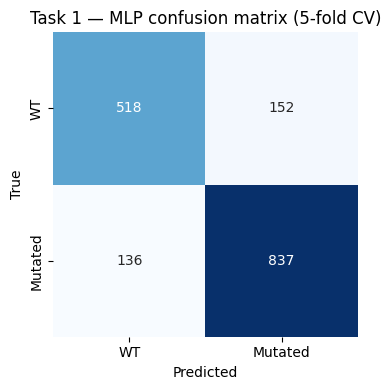

In [ ]:
if RUN_HEAVY:
    print('Run `python scripts/compute_mlp.py` to (re)generate the MLP CSVs.')

# Carichiamo i risultati gia salvati del modello MLP
mlp_t1 = pd.read_csv(OUTPUT_DIR / 'task1/mlp_results.csv')
cm_t1 = pd.read_csv(OUTPUT_DIR / 'task1/mlp_confusion_matrix.csv', index_col=0)
display(mlp_t1.round(4))

# Matrice di confusione media del modello
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm_t1, annot=True, fmt='d', cmap='Blues', cbar=False,
            ax=ax, square=True)
ax.set_title('Task 1 — MLP confusion matrix (5-fold CV)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

The MLP performs similarly to the classical models, but it doesn't give a significant improvement.

So we consider that the simpler tree-based and linear baselines are sufficient for this task. In this dataset, increasing model complexity does not seem to add much beyond what is already captured by the standard approaches.

## 5. Task 2 — Multi-class classification of mutation type

### 5.1 Two label definitions

There are **two distinct ways** to classify a mutation:

**A. Coding consequence (protein-level, Sequence Ontology):**
synonymous, missense, nonsense (stop-gained), in-frame insertion / deletion, frameshift, start lost, stop lost, …

**B. DNA-level (nucleotide mechanism):**
SNV (single nucleotide variant), MNV (multi-nucleotide), insertion, deletion.

We keep both definitions and compare them using the same modelling pipeline.  
The goal is to understand which label structure is more consistent with gene expression data.

Operational labels:

| Coding consequence | DNA-level |
|---|---|
| `WT` | `WT` |
| `Missense` | `SNV` |
| `Inframe` | `MNV` (DepMap calls these `substitution`) |
| `Truncating` (nonsense + frameshift + splice site) | `Insertion` |
| | `Deletion` |

When a cell line has multiple TP53 mutations, we assign one representative label using the most severe coding consequence. The corresponding DNA-level type is then taken from the same mutation.

In [ ]:
# Carichiamo le label del Task 2 gia costruite
labels = pd.read_csv(OUTPUT_DIR / 'datasets/task2_labels.csv')
print(f'Task 2 labels file: {labels.shape}')
display(labels.head(8))

Task 2 labels file: (1643, 10)


,ModelID,task1_tp53_mutated,task2_mutation_type,task2_mutation_type_int,task2_dna_type,task2_dna_type_int,n_tp53_mutations,worst_variant_type,worst_variant_info,worst_protein_change
0,ACH-001113,1,Missense,1,SNV,1,1,SNV,missense_variant,p.M237I
1,ACH-001289,0,WT,0,WT,0,0,NaN,NaN,NaN
2,ACH-001339,1,Missense,1,SNV,1,1,SNV,missense_variant,p.C135R
3,ACH-001979,0,WT,0,WT,0,0,NaN,NaN,NaN
4,ACH-002438,0,WT,0,WT,0,0,NaN,NaN,NaN
5,ACH-001538,0,WT,0,WT,0,0,NaN,NaN,NaN
6,ACH-000242,0,WT,0,WT,0,0,NaN,NaN,NaN
7,ACH-000708,0,WT,0,WT,0,0,NaN,NaN,NaN


### 5.2 Distribution of both taxonomies


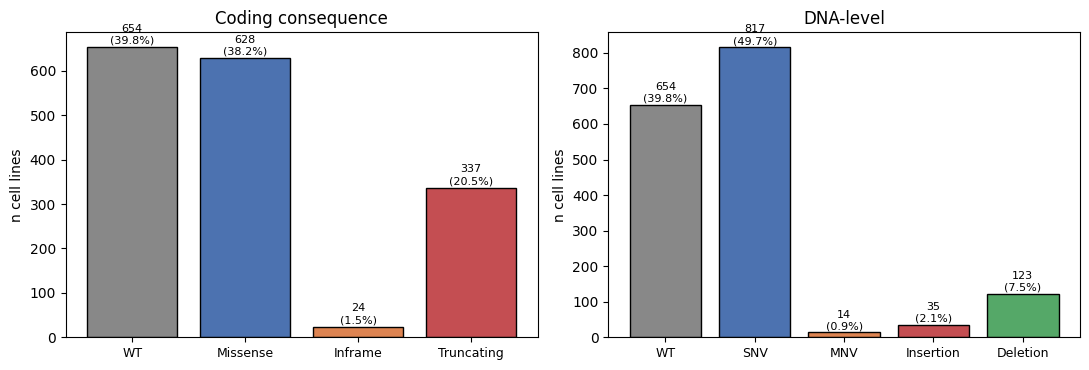

,coding_consequence_n,coding_consequence_pct
task2_mutation_type,,
WT,654,39.8
Missense,628,38.2
Inframe,24,1.5
Truncating,337,20.5


,dna_level_n,dna_level_pct
task2_dna_type,,
WT,654,39.8
SNV,817,49.7
MNV,14,0.9
Insertion,35,2.1
Deletion,123,7.5


In [ ]:
# Confrontiamo la distribuzione delle classi nelle due tassonomie

coding_order = ['WT', 'Missense', 'Inframe', 'Truncating']
dna_order = ['WT', 'SNV', 'MNV', 'Insertion', 'Deletion']

coding_dist = labels['task2_mutation_type'].value_counts().reindex(coding_order)
dna_dist = labels['task2_dna_type'].value_counts().reindex(dna_order)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for ax, dist, title in zip(axes, [coding_dist, dna_dist], ['Coding consequence', 'DNA-level']):
    bars = ax.bar(dist.index, dist.values, color=['#888', '#4C72B0', '#DD8452', '#C44E52', '#55A868'][:len(dist)],
                  edgecolor='black')
    
    ax.set_title(title)
    ax.set_ylabel('n cell lines')

    for bar, v in zip(bars, dist.values):
        pct = 100 * v / dist.sum()
        ax.text(bar.get_x() + bar.get_width()/2, v + 8, f'{v}\n({pct:.1f}%)', ha='center', fontsize=8)

    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

summary_df = pd.concat([coding_dist.to_frame('coding_consequence_n'),(coding_dist / coding_dist.sum() * 100).round(1).to_frame('coding_consequence_pct'),
], axis=1)

display(summary_df)

summary_df = pd.concat([dna_dist.to_frame('dna_level_n'), (dna_dist / dna_dist.sum() * 100).round(1).to_frame('dna_level_pct'),
], axis=1)
display(summary_df

### 5.3 Crosstab DNA × Coding

The same physical mutations re-labeled both ways:


In [ ]:
# Tabella incrociata tra tassonomia DNA-level e coding consequence

ct = pd.crosstab(labels['task2_dna_type'], labels['task2_mutation_type'], margins=True, margins_name='Total')
ct = ct.reindex(index=['WT', 'SNV', 'MNV', 'Insertion', 'Deletion', 'Total'], columns=['WT', 'Missense', 'Inframe', 'Truncating', 'Total'],)

display(ct.fillna(0).astype(int))

task2_mutation_type,WT,Missense,Inframe,Truncating,Total
task2_dna_type,,,,,
WT,654,0,0,0,654
SNV,0,619,0,198,817
MNV,0,9,0,5,14
Insertion,0,0,3,32,35
Deletion,0,0,21,102,123
Total,654,628,24,337,1643


The crosstab already suggests an important difference between the two label definitions.

- The **DNA-level taxonomy** groups together mutations that may have very different functional effects.
- The **coding-consequence taxonomy** is closer to the expected biological impact on the protein.

Since gene expression is more likely to reflect functional consequences rather than the exact DNA mechanism, we expect the coding-based labels to be easier to predict.

### 5.4 Dropping rare classes

Some classes are too small to support stable multi-class training.

In particular:
- `Inframe` is rare in the coding-consequence taxonomy
- `MNV` is rare in the DNA-level taxonomy

We therefore remove classes with fewer than 30 samples before training.  
This is a conservative choice: it avoids training on classes with too little data and keeps the comparison more reliable.

After filtering:
- coding consequence becomes a 3-class problem
- DNA-level mutation type becomes a 4-class problem

**Why we drop Inframe.**  
Beyond the sample-count threshold, we also checked whether the Inframe class forms a stable group in feature space. Using a PCA-based representation, its centroid is not clearly separated from the other mutated classes, which supports excluding it from training.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import itertools

# Unire labels e master
master_for_eda = master.drop(columns=['task2_mutation_type'], errors='ignore')
df_eda = master_for_eda.merge(labels[['ModelID', 'task2_mutation_type']], on='ModelID', how='inner')
df_eda = df_eda[df_eda['task2_mutation_type'].isin(['Missense', 'Inframe', 'Truncating'])]

metadata_cols = {'ModelID', 'CellLineName', 'CCLEName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype',
    'Sex', 'AgeCategory', 'PrimaryOrMetastasis', 'SequencingID', 'ModelConditionID', 'IsDefaultEntryForMC', 'IsDefaultEntryForModel', 'IsDefaultEntryForModel_bool',
    'TP53_expression', 'TP53_damaging_score','task1_tp53_mutated', 'task2_mutation_type'}

feature_cols_eda = [c for c in df_eda.columns if c not in metadata_cols]

X_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(df_eda[feature_cols_eda].values))
)
y_eda = df_eda['task2_mutation_type'].values

centroids = {c: X_pca[y_eda == c].mean(axis=0) for c in ['Missense', 'Inframe', 'Truncating']}
rows = []
for a, b in itertools.combinations(['Missense', 'Inframe', 'Truncating'], 2):
    rows.append({'pair': f'{a} vs {b}', 'distance_PCA50': round(float(np.linalg.norm(centroids[a] - centroids[b])), 2),})

centroid_distances = pd.DataFrame(rows).sort_values('distance_PCA50').reset_index(drop=True)
display(centroid_distances)

,pair,distance_PCA50
0,Missense vs Truncating,7.47
1,Missense vs Inframe,17.09
2,Inframe vs Truncating,17.81


In practice, the Inframe centroid is almost equidistant from Missense and Truncating.  
This suggests that the class is too small and unstable to define a reliable decision boundary, so removing it is more reasonable than forcing the model to learn it.

### 5.5 Training — same pipeline on both labels

We train the same three classifiers on both label definitions:
- Logistic Regression
- Random Forest
- XGBoost

All models are evaluated with stratified 5-fold cross-validation.  
We keep the training pipeline as similar as possible across the two taxonomies so that the comparison depends mainly on the label definition, not on different modelling choices.

In [ ]:
if RUN_HEAVY:
    # Rirunna l'intera pipeline della Task 2 (lenta)
    import subprocess, sys
    print('[RUN_HEAVY] Launching scripts/train_task2.py...')
    result = subprocess.run([sys.executable, 'scripts/train_task2.py'], capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr)
else:
    print('[skip] Loading pre-computed Task 2 results from output_tp53/.')
    print('       Set RUN_HEAVY=True at the top of the notebook to re-run.')

[skip] Loading pre-computed Task 2 results from output_tp53/.
       Set RUN_HEAVY=True at the top of the notebook to re-run.


### 5.6 Results — side-by-side comparison


In [ ]:
# Confronto finale tra modelli e tra le due definizioni di label

task2 = pd.read_csv(OUTPUT_DIR / 'task2/taxonomy_comparison.csv')
display(task2.round(4))

,label,model,n_classes,n_samples,accuracy,macro_f1,weighted_f1,f1_Missense,f1_Truncating,f1_WT,f1_Deletion,f1_Insertion,f1_SNV
0,coding,LogReg,3,1619,0.6479,0.6025,0.6453,0.6043,0.3836,0.8196,NaN,NaN,NaN
1,coding,RandomForest,3,1619,0.6170,0.4716,0.5557,0.6300,0.0287,0.7560,NaN,NaN,NaN
2,coding,XGBoost,3,1619,0.6800,0.5632,0.6394,0.6767,0.1646,0.8481,NaN,NaN,NaN
3,dna,LogReg,4,1629,0.7477,0.4539,0.7284,NaN,NaN,0.8113,0.0899,0.1304,0.7838
4,dna,RandomForest,4,1629,0.7256,0.3795,0.6869,NaN,NaN,0.7431,0.0000,0.0000,0.7748
5,dna,XGBoost,4,1629,0.7839,0.4129,0.7447,NaN,NaN,0.8362,0.0000,0.0000,0.8154


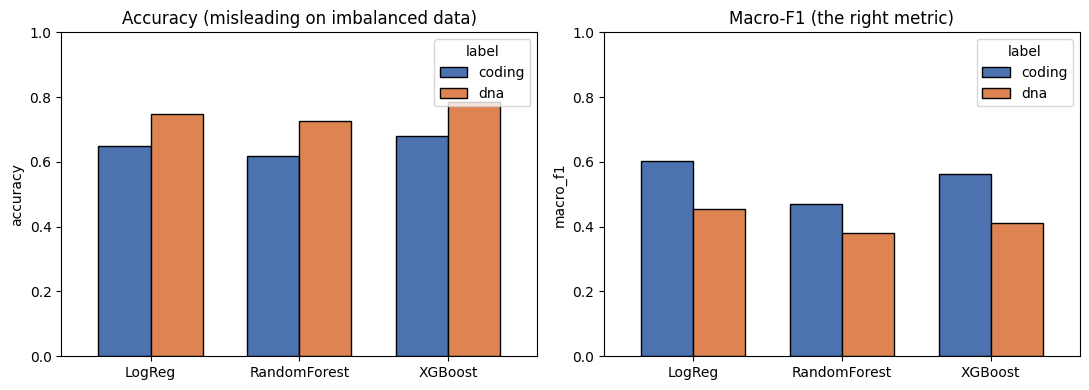

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric, title in zip(
    axes,
    ['accuracy', 'macro_f1'],
    ['Accuracy (misleading on imbalanced data)', 'Macro-F1 (the right metric)'],
):
    pivot = task2.pivot(index='model', columns='label', values=metric)
    pivot[['coding', 'dna']].plot(kind='bar', ax=ax, width=0.7, color=['#4C72B0', '#DD8452'], edgecolor='black')
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=0)
    ax.legend(title='label', loc='upper right')

plt.tight_layout()
plt.show()

The results depend strongly on the evaluation metric.

- On **accuracy**, the DNA-level taxonomy may appear competitive.
- On **macro-F1**, the coding-consequence taxonomy performs better across models.

We focus on **macro-F1** because this is an imbalanced multi-class problem.  
Unlike accuracy, macro-F1 gives the same importance to each class and highlights whether the model is ignoring smaller classes.

### 5.7 Confusion matrices — where the errors go


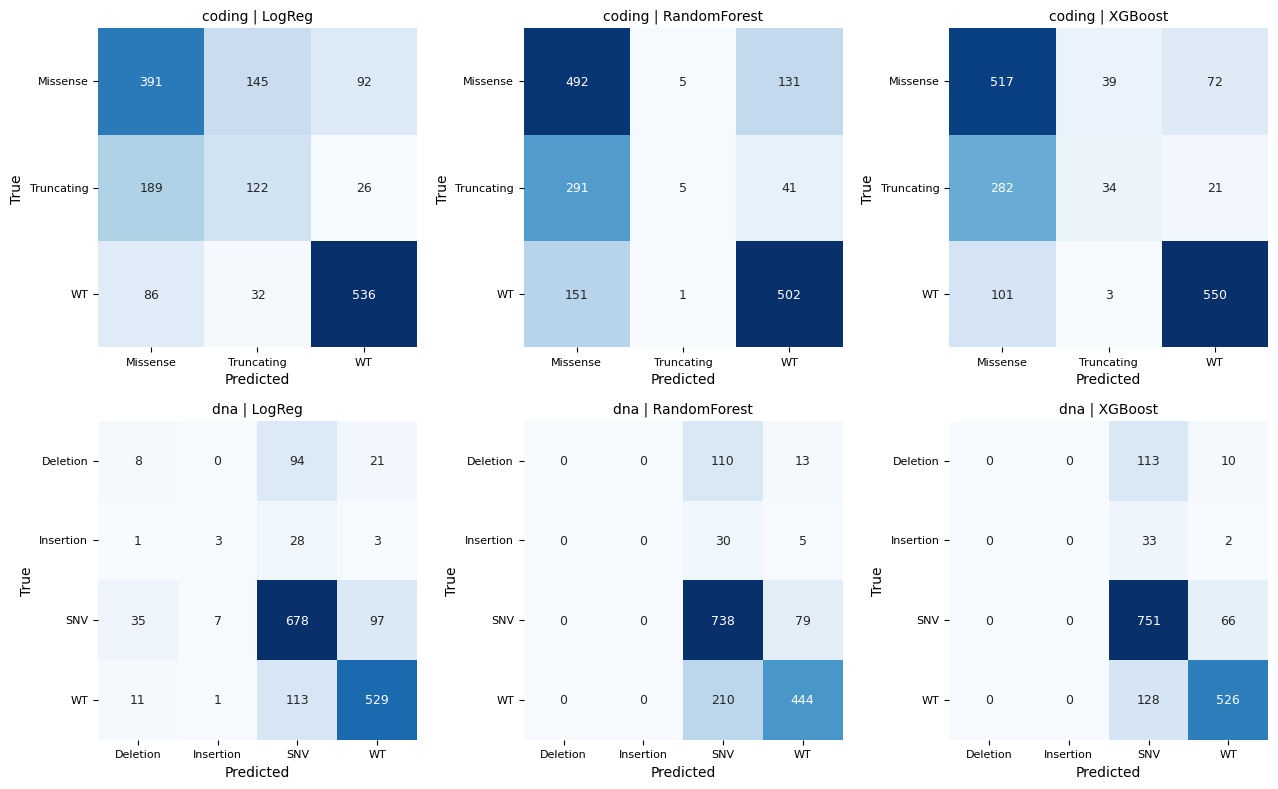

In [ ]:
# Matrici di confusione per capire dove si concentrano gli errori

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

configs = [
    ('coding', 'LogReg'),       ('coding', 'RandomForest'),    ('coding', 'XGBoost'),
    ('dna',    'LogReg'),       ('dna',    'RandomForest'),    ('dna',    'XGBoost'),
]

for ax, (label_name, model_name) in zip(axes.flat, configs):
    cm = pd.read_csv(OUTPUT_DIR / f'task2/cm_{label_name}_{model_name}.csv', index_col=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True, ax=ax, annot_kws={'fontsize': 9})
    ax.set_title(f'{label_name} | {model_name}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

**Key observations from the confusion matrices:**

**Coding consequence.**  
The models recover WT reasonably well, and they also identify many Missense samples.  
The most difficult class is Truncating, which is often confused with Missense. This is still biologically plausible, since both classes correspond to altered TP53 function.

**DNA-level taxonomy.**  
The rare classes are much harder to recover. In particular, some models almost never predict Insertion or Deletion, which suggests that the DNA-level labels are less aligned with the expression signal.

### 5.8 MLP (PyTorch) — Task 2 multi-class

As an additional comparison, we apply the same MLP architecture used in Task 1 to the coding-consequence labels after rare-class filtering.

The goal is not to build a highly optimized deep model, but to check whether a neural-network approach improves over the standard baselines on this multi-class setting.

,task,n_samples,accuracy,macro_f1,weighted_f1
0,task2_coding,1619,0.6189,0.576,0.6188


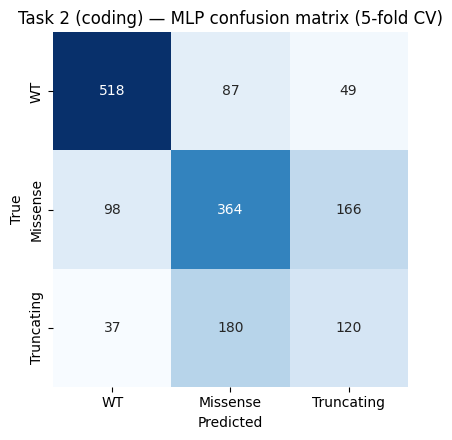


All Task 2 (coding 3-class) models, head to head:


,model,accuracy,macro_f1,weighted_f1
0,LogReg,0.6479,0.6025,0.6453
1,RandomForest,0.6170,0.4716,0.5557
2,XGBoost,0.6800,0.5632,0.6394
3,MLP (PyTorch),0.6189,0.5760,0.6188


In [ ]:
# Carichiamo i risultati gia salvati dell'MLP sul Task 2

if RUN_HEAVY:
    print('Run `python scripts/compute_mlp.py` to (re)generate the MLP CSVs.')

mlp_t2 = pd.read_csv(OUTPUT_DIR / 'task2/mlp_results.csv')
cm_t2 = pd.read_csv(OUTPUT_DIR / 'task2/mlp_confusion_matrix.csv', index_col=0)
display(mlp_t2.round(4))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_t2, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, square=True)
ax.set_title('Task 2 (coding) — MLP confusion matrix (5-fold CV)')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# Side-by-side comparison with the classical models
task2_baseline = pd.read_csv(OUTPUT_DIR / 'task2/taxonomy_comparison.csv')
coding_only = task2_baseline[task2_baseline['label'] == 'coding'][['model', 'accuracy', 'macro_f1', 'weighted_f1']]
mlp_row = mlp_t2[['accuracy', 'macro_f1', 'weighted_f1']].copy()
mlp_row.insert(0, 'model', 'MLP (PyTorch)')
comparison = pd.concat([coding_only, mlp_row], ignore_index=True)
print('\nAll Task 2 (coding 3-class) models, head to head:')
display(comparison.round(4))

The MLP achieves performance similar to the other models, with only a small difference in macro-F1.

Overall, this suggests that model complexity is not the main limitation in Task 2.  
The main difficulty comes from the structure of the labels and from the overlap between mutation classes in the expression space.

### 5.9 Summary of Task 2

Task 2 suggests that **coding consequence** is the more suitable label definition for prediction from gene expression.

Three points support this conclusion:
1. Macro-F1 is consistently higher for coding-consequence labels
2. The confusion matrices are more interpretable on the coding side
3. The DNA-level taxonomy makes the rare classes harder to separate

Overall, gene expression appears to reflect the functional impact of TP53 alterations more than the exact nucleotide-level mutation mechanism.

## 6. Limitations

This project has a few important limitations.

1. **CCLE-only analysis.** We worked on cancer cell lines, which are useful and easier to handle than patient data, but they do not fully represent the complexity of real tumors.

2. **Tissue effects.** In Task 1 we showed that tissue identity already carries part of the predictive signal. This means that some of the performance may depend on tissue context and not only on TP53 status.

3. **Rare classes in Task 2.** Some mutation classes were too small to support stable multi-class training, so we removed them before fitting the models.

4. **Limited tuning.** We only performed a small amount of hyperparameter tuning, because our goal was to compare reasonable baseline models rather than optimize every model as much as possible.

## 7. Conclusions

In this project, we used gene expression data from CCLE to predict TP53 mutation status with supervised machine learning models.

For **Task 1**, the results show that TP53 mutated vs WT can be predicted with good performance from expression data. The comparison across validation settings also suggests that part of the signal is related to tissue identity, but not all of it.

For **Task 2**, the coding-consequence labels were easier to predict than the DNA-level mutation labels. This suggests that gene expression reflects the functional impact of TP53 alterations more clearly than the exact nucleotide-level mutation mechanism.

Overall, the project shows that transcriptomic data contain useful information about TP53 status, and that standard machine learning models are already sufficient to capture a meaningful part of this signal.